# xr and tensordict

The idea is to go only to string at the presentation level, and always work with datetime objects behind the scenes.

In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
cd ..

/Users/alain/Desktop/master-thesis/guiding-generative-probabilistic-weather-models


In [4]:
import sys
import numpy as np

In [5]:
from datetime import datetime, timezone, timedelta

In [6]:
from src.utils.dataset_utils import *

DATA path: /Users/alain/switchdrive


In [7]:
ds = get_arches_era5()

## explore

In [8]:
print(f"{ds.nbytes / 1_000_000_000:.2f} GB")

13.94 GB


In [9]:
ds

<xarray.Dataset> Size: 14GB
Dimensions:                  (time: 1464, latitude: 121, longitude: 240,
                              level: 13)
Coordinates:
  * time                     (time) datetime64[ns] 12kB 2020-01-01 ... 2020-1...
  * latitude                 (latitude) float64 968B 90.0 88.5 ... -88.5 -90.0
  * longitude                (longitude) float64 2kB -180.0 -178.5 ... 178.5
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
Data variables:
    10m_u_component_of_wind  (time, latitude, longitude) float32 170MB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 170MB ...
    2m_temperature           (time, latitude, longitude) float32 170MB ...
    geopotential             (time, level, latitude, longitude) float32 2GB ...
    mean_sea_level_pressure  (time, latitude, longitude) float32 170MB ...
    specific_humidity        (time, level, latitude, longitude) float32 2GB ...
    temperature              (time, level, latitude, longitude) float32 2GB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 2GB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 2GB ...
    vertical_velocity        (time, level, latitude, longitude) float32 2GB ...

In [10]:
ds.time, ds.time[0].item(), ds.time[-1].item()

(<xarray.DataArray 'time' (time: 1464)> Size: 12kB
 array(['2020-01-01T00:00:00.000000000', '2020-01-01T06:00:00.000000000',
        '2020-01-01T12:00:00.000000000', ..., '2020-12-31T06:00:00.000000000',
        '2020-12-31T12:00:00.000000000', '2020-12-31T18:00:00.000000000'],
       shape=(1464,), dtype='datetime64[ns]')
 Coordinates:
   * time     (time) datetime64[ns] 12kB 2020-01-01 ... 2020-12-31T18:00:00,
 1577836800000000000,
 1609437600000000000)

In [11]:
# nanoseconds precision, 
# datetime64[ns] is the general dtype
# <M8[ns] is the machine specific format (little endian machines)
ds.time[0].dtype

dtype('<M8[ns]')

In [12]:
# names
ds.dims

FrozenMappingWarningOnValuesAccess({'time': 1464, 'latitude': 121, 'longitude': 240, 'level': 13})

In [13]:
ds.coords

Coordinates:
  * time       (time) datetime64[ns] 12kB 2020-01-01 ... 2020-12-31T18:00:00
  * latitude   (latitude) float64 968B 90.0 88.5 87.0 85.5 ... -87.0 -88.5 -90.0
  * longitude  (longitude) float64 2kB -180.0 -178.5 -177.0 ... 177.0 178.5
  * level      (level) int64 104B 50 100 150 200 250 ... 600 700 850 925 1000

In [14]:
ds.level

<xarray.DataArray 'level' (level: 13)> Size: 104B
array([  50,  100,  150,  200,  250,  300,  400,  500,  600,  700,  850,  925,
       1000])
Coordinates:
  * level    (level) int64 104B 50 100 150 200 250 300 ... 600 700 850 925 1000

In [15]:
ds.sizes, ds.dtypes

(Frozen({'time': 1464, 'latitude': 121, 'longitude': 240, 'level': 13}),
 Frozen({'10m_u_component_of_wind': dtype('float32'), '10m_v_component_of_wind': dtype('float32'), '2m_temperature': dtype('float32'), 'geopotential': dtype('float32'), 'mean_sea_level_pressure': dtype('float32'), 'specific_humidity': dtype('float32'), 'temperature': dtype('float32'), 'u_component_of_wind': dtype('float32'), 'v_component_of_wind': dtype('float32'), 'vertical_velocity': dtype('float32')}))

In [16]:
ds.data_vars

Data variables:
    10m_u_component_of_wind  (time, latitude, longitude) float32 170MB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 170MB ...
    2m_temperature           (time, latitude, longitude) float32 170MB ...
    geopotential             (time, level, latitude, longitude) float32 2GB ...
    mean_sea_level_pressure  (time, latitude, longitude) float32 170MB ...
    specific_humidity        (time, level, latitude, longitude) float32 2GB ...
    temperature              (time, level, latitude, longitude) float32 2GB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 2GB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 2GB ...
    vertical_velocity        (time, level, latitude, longitude) float32 2GB ...

In [17]:
ds.keys()

KeysView(<xarray.Dataset> Size: 14GB
Dimensions:                  (time: 1464, latitude: 121, longitude: 240,
                              level: 13)
Coordinates:
  * time                     (time) datetime64[ns] 12kB 2020-01-01 ... 2020-1...
  * latitude                 (latitude) float64 968B 90.0 88.5 ... -88.5 -90.0
  * longitude                (longitude) float64 2kB -180.0 -178.5 ... 178.5
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
Data variables:
    10m_u_component_of_wind  (time, latitude, longitude) float32 170MB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 170MB ...
    2m_temperature           (time, latitude, longitude) float32 170MB ...
    geopotential             (time, level, latitude, longitude) float32 2GB ...
    mean_sea_level_pressure  (time, latitude, longitude) float32 170MB ...
    specific_humidity        (time, level, latitude, longitude) float32 2GB ...
    temperature              (time, level, 

## data logic

In [53]:
from src.utils.converters import string_to_datetime, datetime_to_string

In [56]:
timestamp = string_to_datetime("2026-05-19T15:51:42")
datetime_to_string(timestamp)
datetime.strftime(timestamp, "%Y-%m-%dT%H:%M:%S")

'2026-05-19T15:51:42'

In [18]:
ns_ts = ds.time[0].item()

In [19]:
# convert to seconds before using fromtimestamp
ns_ts / 10**9

1577836800.0

In [20]:
dt_utc = datetime.fromtimestamp(ns_ts / 10**9, tz=timezone.utc)
dt_utc

datetime.datetime(2020, 1, 1, 0, 0, tzinfo=datetime.timezone.utc)

In [21]:
str(dt_utc)

'2020-01-01 00:00:00+00:00'

In [22]:
# will not work because it has the tzinfo
ds.sel(time=dt_utc)

KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."

In [23]:
dt_display = dt_utc.replace(tzinfo=None)
dt_display

datetime.datetime(2020, 1, 1, 0, 0)

In [24]:
ds.sel(time=dt_display)

<xarray.Dataset> Size: 10MB
Dimensions:                  (latitude: 121, longitude: 240, level: 13)
Coordinates:
  * latitude                 (latitude) float64 968B 90.0 88.5 ... -88.5 -90.0
  * longitude                (longitude) float64 2kB -180.0 -178.5 ... 178.5
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
    time                     datetime64[ns] 8B 2020-01-01
Data variables:
    10m_u_component_of_wind  (latitude, longitude) float32 116kB ...
    10m_v_component_of_wind  (latitude, longitude) float32 116kB ...
    2m_temperature           (latitude, longitude) float32 116kB ...
    geopotential             (level, latitude, longitude) float32 2MB ...
    mean_sea_level_pressure  (latitude, longitude) float32 116kB ...
    specific_humidity        (level, latitude, longitude) float32 2MB ...
    temperature              (level, latitude, longitude) float32 2MB ...
    u_component_of_wind      (level, latitude, longitude) float32 2MB ...
    v_component_of_wind      (level, latitude, longitude) float32 2MB ...
    vertical_velocity        (level, latitude, longitude) float32 2MB ...

In [25]:
str(dt_display)

'2020-01-01 00:00:00'

In [26]:
N = 10
dt_N_from_ts = dt_display + timedelta(days=N)
dt_N_from_ts

datetime.datetime(2020, 1, 11, 0, 0)

In [27]:
time_slice = slice(dt_display, dt_N_from_ts, 4)
time_slice

slice(datetime.datetime(2020, 1, 1, 0, 0), datetime.datetime(2020, 1, 11, 0, 0), 4)

In [28]:
ds.sel(time=time_slice).time

<xarray.DataArray 'time' (time: 11)> Size: 88B
array(['2020-01-01T00:00:00.000000000', '2020-01-02T00:00:00.000000000',
       '2020-01-03T00:00:00.000000000', '2020-01-04T00:00:00.000000000',
       '2020-01-05T00:00:00.000000000', '2020-01-06T00:00:00.000000000',
       '2020-01-07T00:00:00.000000000', '2020-01-08T00:00:00.000000000',
       '2020-01-09T00:00:00.000000000', '2020-01-10T00:00:00.000000000',
       '2020-01-11T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 88B 2020-01-01 2020-01-02 ... 2020-01-11

In [29]:
# or alternatively
date_list = [dt_display + timedelta(days=n) for n in range(N)]
date_list

[datetime.datetime(2020, 1, 1, 0, 0),
 datetime.datetime(2020, 1, 2, 0, 0),
 datetime.datetime(2020, 1, 3, 0, 0),
 datetime.datetime(2020, 1, 4, 0, 0),
 datetime.datetime(2020, 1, 5, 0, 0),
 datetime.datetime(2020, 1, 6, 0, 0),
 datetime.datetime(2020, 1, 7, 0, 0),
 datetime.datetime(2020, 1, 8, 0, 0),
 datetime.datetime(2020, 1, 9, 0, 0),
 datetime.datetime(2020, 1, 10, 0, 0)]

In [30]:
ds.sel(time=date_list).time

<xarray.DataArray 'time' (time: 10)> Size: 80B
array(['2020-01-01T00:00:00.000000000', '2020-01-02T00:00:00.000000000',
       '2020-01-03T00:00:00.000000000', '2020-01-04T00:00:00.000000000',
       '2020-01-05T00:00:00.000000000', '2020-01-06T00:00:00.000000000',
       '2020-01-07T00:00:00.000000000', '2020-01-08T00:00:00.000000000',
       '2020-01-09T00:00:00.000000000', '2020-01-10T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 80B 2020-01-01 2020-01-02 ... 2020-01-10

In [31]:
timestamp = dt_display
slice_ = ds.sel(time=timestamp)
var = "temperature"
level = 50
slice_ = slice_[var]  # only for data_vars
slice_ = slice_.sel(level=level)
slice_

# slice_ = slice_.to_numpy()

<xarray.DataArray 'temperature' (latitude: 121, longitude: 240)> Size: 116kB
[29040 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float64 968B 90.0 88.5 87.0 85.5 ... -87.0 -88.5 -90.0
  * longitude  (longitude) float64 2kB -180.0 -178.5 -177.0 ... 177.0 178.5
    level      int64 8B 50
    time       datetime64[ns] 8B 2020-01-01
Attributes:
    long_name:      Temperature
    short_name:     t
    standard_name:  air_temperature
    units:          K

In [32]:
assert dt_display.tzinfo is None
# as expected!
assert dt_utc.tzinfo is None

AssertionError: 

## dataset API

In [33]:
partition = "surface"
var = "2m_temperature"
level = 0
N = 1
timestamp = dt_display

In [ ]:
def get_N_timestamps(timestamp: datetime, N: int) -> list[datetime]:
    return [timestamp + timedelta(days=n) for n in range(N)]

In [35]:
def get_N_states(ds: xr.Dataset, N: int, timestamp: datetime):
    assert timestamp.tzinfo is None 
    # alternatively
    # timestamp = timestamp.replace(tzinfo=None)
    timestamps = get_N_timestamps(timestamp, N)
    return ds.sel(time=timestamps)

N_states = get_N_states(ds, N, timestamp)
N_states

<xarray.Dataset> Size: 10MB
Dimensions:                  (time: 1, latitude: 121, longitude: 240, level: 13)
Coordinates:
  * time                     (time) datetime64[ns] 8B 2020-01-01
  * latitude                 (latitude) float64 968B 90.0 88.5 ... -88.5 -90.0
  * longitude                (longitude) float64 2kB -180.0 -178.5 ... 178.5
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
Data variables:
    10m_u_component_of_wind  (time, latitude, longitude) float32 116kB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 116kB ...
    2m_temperature           (time, latitude, longitude) float32 116kB ...
    geopotential             (time, level, latitude, longitude) float32 2MB ...
    mean_sea_level_pressure  (time, latitude, longitude) float32 116kB ...
    specific_humidity        (time, level, latitude, longitude) float32 2MB ...
    temperature              (time, level, latitude, longitude) float32 2MB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 2MB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 2MB ...
    vertical_velocity        (time, level, latitude, longitude) float32 2MB ...

In [36]:
def get_slices(states: xr.Dataset, partition: str, var: str, level: str):
    assert timestamp.tzinfo is None 
    # alternatively
    # timestamp = timestamp.replace(tzinfo=None)
    slices = states[var]
    if partition == "level":
        slices = slices.sel(level=level)
    slices = slices.to_numpy()
    return slices

N_slices = get_slices(N_states, partition, var, level)
N_slices.shape

(1, 121, 240)

In [37]:
def get_N_slices(ds: xr.Dataset, N: int, timestamp: datetime, partition: str, var: str, level: str):
    N_states = get_N_states(ds, N, timestamp)
    N_slices = get_slices(N_states, partition, var, level)
    return N_slices

N_slices = get_N_slices(
    ds,
    N=N,
    timestamp=timestamp,
    partition=partition,
    var=var,
    level=level
)
N_slices.shape, type(N_slices), N_slices.dtype

((1, 121, 240), numpy.ndarray, dtype('float32'))

In [38]:
def get_slices_mean(N_slices: np.ndarray):
    return np.mean(N_slices, axis=(1,2))

get_slices_mean(N_slices)

array([277.00464], dtype=float32)

In [39]:
from src.mask import get_normal_mask

In [40]:
mask = get_normal_mask((100, 100), (20, 30))
def get_masked_slices(N_slices: np.ndarray, mask: np.ndarray):
    return N_slices * mask

masked_slices = get_masked_slices(N_slices, mask)

In [41]:
get_slices_mean(masked_slices)

array([0.00956456])

In [42]:
def get_dt_timestamp(timestamp: str):
    pass

def get_timestamps(ds: xr.Dataset):
    timestamps = []
    for i in range(len(ds.time)):
        ns_ts = ds.time[i].item()
        dt_utc = datetime.fromtimestamp(ns_ts / 10**9, tz=timezone.utc)
        dt_display = dt_utc.replace(tzinfo=None)
        dt = str(dt_display)
        timestamps.append(dt)

    return timestamps

get_timestamps(ds)[:3]

['2020-01-01 00:00:00', '2020-01-01 06:00:00', '2020-01-01 12:00:00']

In [43]:
first_slice = N_slices[0]

In [44]:
import matplotlib.pyplot as plt

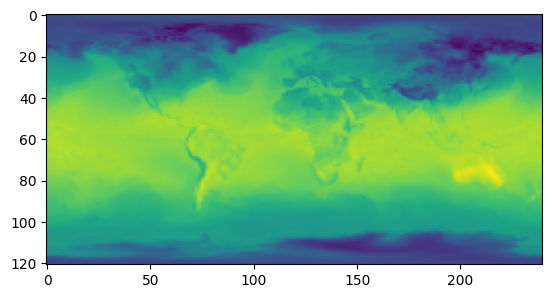

In [45]:
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(first_slice)
plt.show()